# Stage 2 — Data exploration

Inspect the train/val/test splits produced by `python -m src.dataset build`.
Sections:
1. Load splits and label map
2. Class distribution **before** oversampling
3. Class distribution **after** oversampling (train only)
4. Leakage verification
5. PCA on a random training subsample
6. Feature sanity checks
7. Written interpretation

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SPLITS_DIR = REPO_ROOT / 'data' / 'splits'
LABELS_PATH = REPO_ROOT / 'data' / 'labels.json'

with open(LABELS_PATH) as f:
    label_to_id = json.load(f)
id_to_name = {v: k for k, v in label_to_id.items()}
CLASS_IDS = sorted(id_to_name.keys())

def load_split(name):
    z = np.load(SPLITS_DIR / f'{name}.npz', allow_pickle=True)
    return {k: z[k] for k in z.files}

splits = {n: load_split(n) for n in ('train', 'val', 'test')}
for name, s in splits.items():
    print(f'{name:6s} X={s["X"].shape} y={s["y"].shape} synthetic={int(s["is_synthetic"].sum())} augmented={int(s["is_augmented"].sum())}')

train  X=(415420, 279) y=(415420,) synthetic=65000 augmented=60762
val    X=(41108, 279) y=(41108,) synthetic=55 augmented=0
test   X=(40895, 279) y=(40895,) synthetic=57 augmented=0


## 2. Class distribution before oversampling

Counts include real + un-augmented synthetic rows only. Train counts 6-18 (class IDs 15-27) are visibly low — this motivates the oversampling step.

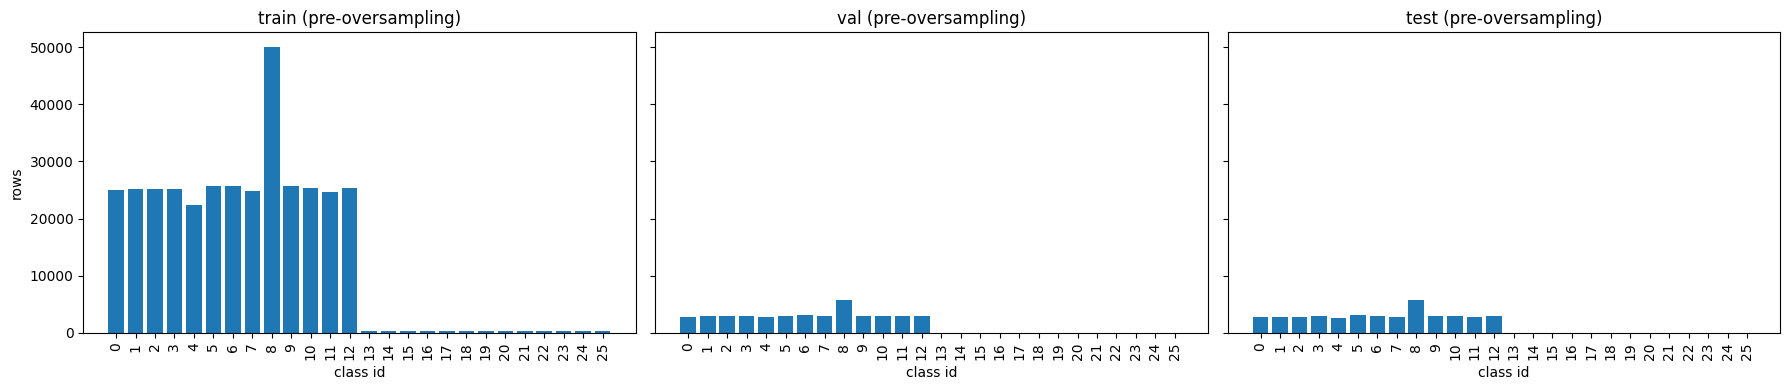

train pre-oversampling per class:
   0  thumbs_up        25016
   1  thumbs_down      25237
   2  stop             25213
   3  ok               25137
   4  call             22409
   5  rock             25661
   6  mute             25721
   7  fist             24863
   8  peace            50089
   9  open_palm        25715
  10  count_1          25416
  11  count_3          24633
  12  count_4          25310
  13  count_6            336
  14  count_7            313
  15  count_8            349
  16  count_9            321
  17  count_10           331
  18  count_11           325
  19  count_12           312
  20  count_13           333
  21  count_14           314
  22  count_15           335
  23  count_16           331
  24  count_17           317
  25  count_18           321


In [2]:
def class_counts(y, mask=None):
    if mask is not None:
        y = y[mask]
    return np.array([int(np.sum(y == c)) for c in CLASS_IDS])

pre_counts = {}
for name, s in splits.items():
    pre_counts[name] = class_counts(s['y'], mask=~s['is_augmented'].astype(bool))

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, name in zip(axes, ('train', 'val', 'test')):
    ax.bar(CLASS_IDS, pre_counts[name])
    ax.set_title(f'{name} (pre-oversampling)')
    ax.set_xlabel('class id')
    ax.set_xticks(CLASS_IDS)
    ax.tick_params(axis='x', labelrotation=90)
axes[0].set_ylabel('rows')
plt.tight_layout()
plt.show()

print('train pre-oversampling per class:')
for c in CLASS_IDS:
    print(f'  {c:>2d}  {id_to_name[c]:<14s} {pre_counts["train"][c]:>7d}')

## 3. Class distribution after oversampling

Full train distribution including augmented duplicates. Count classes 15-27 should be at ~5,000. Val/test are unchanged (no augmentation).

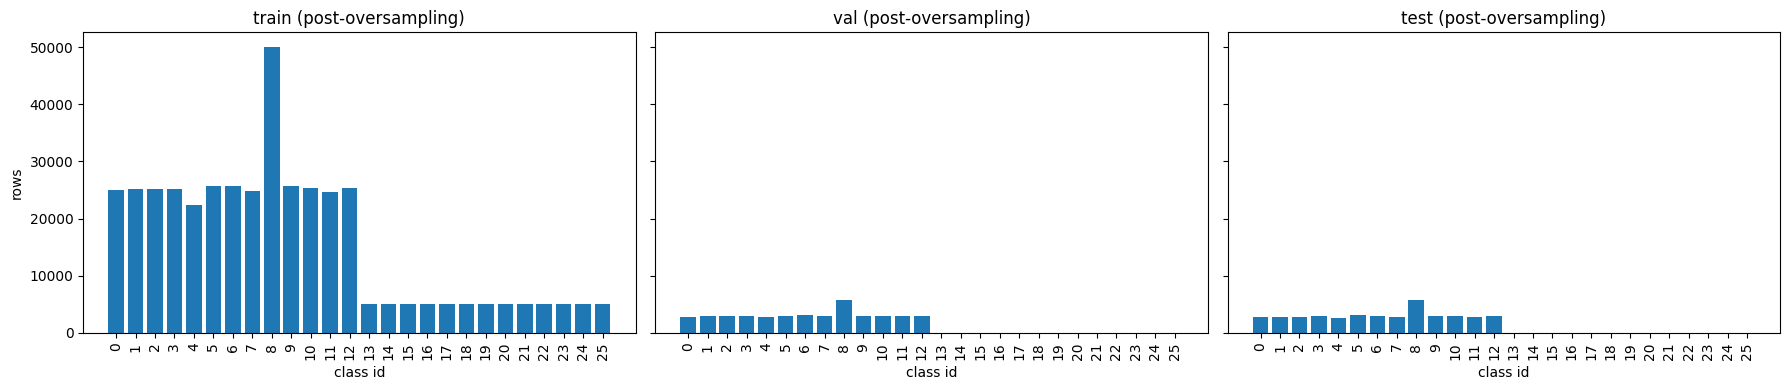

train post-oversampling per class:
   0  thumbs_up        25016
   1  thumbs_down      25237
   2  stop             25213
   3  ok               25137
   4  call             22409
   5  rock             25661
   6  mute             25721
   7  fist             24863
   8  peace            50089
   9  open_palm        25715
  10  count_1          25416
  11  count_3          24633
  12  count_4          25310
  13  count_6           5000 (oversampled)
  14  count_7           5000 (oversampled)
  15  count_8           5000 (oversampled)
  16  count_9           5000 (oversampled)
  17  count_10          5000 (oversampled)
  18  count_11          5000 (oversampled)
  19  count_12          5000 (oversampled)
  20  count_13          5000 (oversampled)
  21  count_14          5000 (oversampled)
  22  count_15          5000 (oversampled)
  23  count_16          5000 (oversampled)
  24  count_17          5000 (oversampled)
  25  count_18          5000 (oversampled)

val/test contain no augmente

In [3]:
post_counts = {name: class_counts(s['y']) for name, s in splits.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, name in zip(axes, ('train', 'val', 'test')):
    ax.bar(CLASS_IDS, post_counts[name])
    ax.set_title(f'{name} (post-oversampling)')
    ax.set_xlabel('class id')
    ax.set_xticks(CLASS_IDS)
    ax.tick_params(axis='x', labelrotation=90)
axes[0].set_ylabel('rows')
plt.tight_layout()
plt.show()

print('train post-oversampling per class:')
for c in CLASS_IDS:
    delta = post_counts['train'][c] - pre_counts['train'][c]
    marker = ' (oversampled)' if delta > 0 else ''
    print(f'  {c:>2d}  {id_to_name[c]:<14s} {post_counts["train"][c]:>7d}{marker}')

assert not bool(splits['val']['is_augmented'].any()), 'val should have no augmented rows'
assert not bool(splits['test']['is_augmented'].any()), 'test should have no augmented rows'
print('\nval/test contain no augmented rows: OK')

## 4. Leakage verification

In [4]:
real_users = {}
for name, s in splits.items():
    is_syn = s['is_synthetic'].astype(bool)
    uid = s['user_id'].astype(str)
    real_users[name] = set(uid[~is_syn].tolist())
    print(f'{name:6s} real users: {len(real_users[name])}')

for a, b in (('train','val'), ('train','test'), ('val','test')):
    overlap = real_users[a] & real_users[b]
    print(f'  {a} & {b} overlap = {len(overlap)} (expected 0)')
    assert not overlap, f'{a}/{b} user leakage'

for name, s in splits.items():
    is_syn = s['is_synthetic'].astype(bool)
    if not is_syn.any():
        continue
    syn_users = set(s['synth_right_user'][is_syn].astype(str).tolist()) | \
                set(s['synth_left_user'][is_syn].astype(str).tolist())
    assert syn_users.issubset(real_users[name]), f'{name}: synth source users outside split'
    for other in ('train', 'val', 'test'):
        if other == name:
            continue
        assert syn_users.isdisjoint(real_users[other]), f'{name}/{other}: synthetic source user leak'
print('no user_id leakage detected (real + synthetic source users)')

train  real users: 27034
val    real users: 3379
test   real users: 3380
  train & val overlap = 0 (expected 0)
  train & test overlap = 0 (expected 0)
  val & test overlap = 0 (expected 0)


no user_id leakage detected (real + synthetic source users)


## 5. PCA on random training subsample

Project 5,000 random training rows onto PC1+PC2. Visible cluster structure validates the engineered feature space.

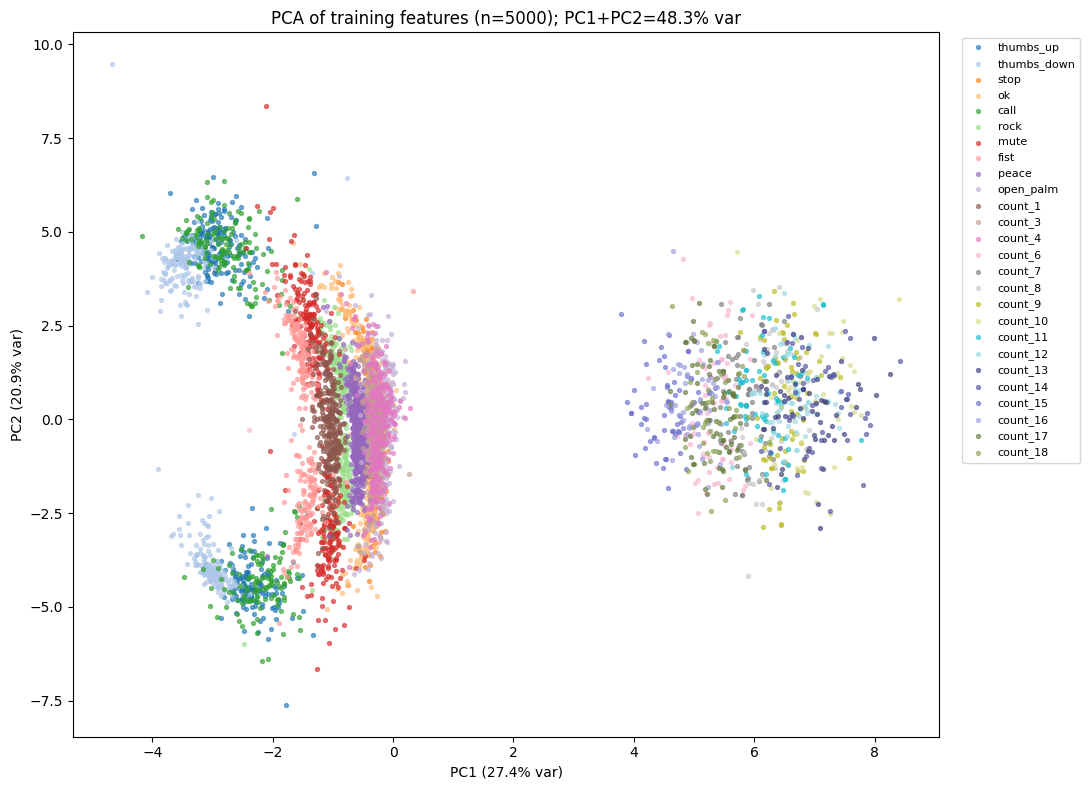

PC1 explained variance: 27.42%
PC2 explained variance: 20.88%


In [5]:
rng = np.random.default_rng(20260514)
X_train = splits['train']['X']
y_train = splits['train']['y']
n_sub = min(5000, X_train.shape[0])
sub_idx = rng.choice(X_train.shape[0], size=n_sub, replace=False)
X_sub = X_train[sub_idx]
y_sub = y_train[sub_idx]

pca = PCA(n_components=2, random_state=20260514)
X_pca = pca.fit_transform(X_sub)
evr = pca.explained_variance_ratio_

palette = sns.color_palette('tab20', 20) + sns.color_palette('tab20b', 8)
fig, ax = plt.subplots(figsize=(11, 8))
for c in CLASS_IDS:
    mask = y_sub == c
    if not mask.any():
        continue
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=8, alpha=0.6,
               color=palette[c % len(palette)], label=id_to_name[c])
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}% var)')
ax.set_title(f'PCA of training features (n={n_sub}); PC1+PC2={evr.sum()*100:.1f}% var')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=1)
plt.tight_layout()
plt.show()

print(f'PC1 explained variance: {evr[0]*100:.2f}%')
print(f'PC2 explained variance: {evr[1]*100:.2f}%')

## 6. Feature sanity checks

Apply invariants to **non-augmented** rows only. Augmented rows intentionally violate the strict wrist-at-origin / palm-norm-=1 invariants (additive Gaussian noise of sigma=0.01).

In [6]:
from src.feature_assembler import RIGHT_PRESENT_IDX, LEFT_PRESENT_IDX, INTER_DIST_IDX

def report(name, ok, detail=''):
    flag = 'OK ' if ok else 'FAIL'
    print(f'  [{flag}] {name}{(" — " + detail) if detail else ""}')
    return bool(ok)

fails = 0
for name, s in splits.items():
    print(f'\n=== {name} ===')
    X = s['X']
    is_syn = s['is_synthetic'].astype(bool)
    is_aug = s['is_augmented'].astype(bool)
    real_mask = ~is_syn & ~is_aug

    fails += not report('no NaN/Inf in X', bool(np.isfinite(X).all()))
    fails += not report('X.shape[1] == 279', X.shape[1] == 279)
    fails += not report('presence flags in {0,1}', np.all(np.isin(X[:, RIGHT_PRESENT_IDX], [0.0,1.0])) and np.all(np.isin(X[:, LEFT_PRESENT_IDX], [0.0,1.0])))
    fails += not report('inter_dist >= 0', bool(np.all(X[:, INTER_DIST_IDX] >= 0.0)))

    if real_mask.any():
        Xr = X[real_mask]
        fails += not report('real rows: wrist at origin (atol 1e-4)', bool(np.allclose(Xr[:, 0:3], 0.0, atol=1e-4)))
        palm = np.linalg.norm(Xr[:, 27:30], axis=1)
        fails += not report('real rows: palm norm ≈ 1.0', bool(np.allclose(palm, 1.0, atol=1e-3)), f'min={palm.min():.4f}, max={palm.max():.4f}')
        ext_r = Xr[:, 123:128]
        fails += not report('real rows: right extension ratios in [0,1]', bool(np.all((ext_r >= 0.0) & (ext_r <= 1.0))))

print(f'\nTotal failures: {fails}')
assert fails == 0, 'feature sanity check failures'


=== train ===
  [OK ] no NaN/Inf in X
  [OK ] X.shape[1] == 279
  [OK ] presence flags in {0,1}
  [OK ] inter_dist >= 0


  [OK ] real rows: wrist at origin (atol 1e-4)
  [OK ] real rows: palm norm ≈ 1.0 — min=0.9994, max=1.0000
  [OK ] real rows: right extension ratios in [0,1]

=== val ===
  [OK ] no NaN/Inf in X
  [OK ] X.shape[1] == 279
  [OK ] presence flags in {0,1}
  [OK ] inter_dist >= 0
  [OK ] real rows: wrist at origin (atol 1e-4)
  [OK ] real rows: palm norm ≈ 1.0 — min=0.9997, max=1.0000
  [OK ] real rows: right extension ratios in [0,1]

=== test ===
  [OK ] no NaN/Inf in X
  [OK ] X.shape[1] == 279
  [OK ] presence flags in {0,1}
  [OK ] inter_dist >= 0
  [OK ] real rows: wrist at origin (atol 1e-4)
  [OK ] real rows: palm norm ≈ 1.0 — min=0.9994, max=1.0000
  [OK ] real rows: right extension ratios in [0,1]

Total failures: 0


## 7. Interpretation

- **Oversampling target**: every count_6..count_18 class should reach 5,000 rows in train. Inspect the printed table in section 3.
- **Leakage**: section 4 must report 0 overlap across all three split pairs and confirm synthetic source users stay inside their split.
- **PCA**: PC1+PC2 typically explain only a small fraction of the variance for engineered 279-dim hand features, so expect overlap. Look for class-coloured clusters separating along PC1/PC2. Faint separation is acceptable for Stage 2 acceptance; it is a signal for Stage 4 architecture tuning, not a blocker.
- **Class coverage in val/test**: counts 6-18 frequently have only a handful of rows in val/test (the synthetic-source-pair rule drops ~33% of rows). This satisfies the "≥1 per class per split" gate; downstream evaluation should use macro F1 with care (per-class metrics for these classes have high variance).